# オニオンアーキテクチャ

## 概要

オニオンアーキテクチャ（Onion Architecture）は、Jeffrey Palermo が2008年のブログ記事群で提唱したソフトウェアアーキテクチャパターン。

ドメインモデルを中心（コア）に据え、そこから同心円状に層を重ねていく構造を取ることから「玉ねぎ（Onion）」と呼ばれる。データベースやUIといったインフラストラクチャをアプリケーションの中心から追い出し、「差し替え可能な詳細」として外側に配置する点が特徴。

クリーンアーキテクチャ（2012年）やヘキサゴナルアーキテクチャ（Ports and Adapters、2005年）とほぼ同じ思想を共有しており、これら3つはしばしば「同じ概念群のバリエーション」として扱われる。オニオンアーキテクチャは時系列的にはヘキサゴナルアーキテクチャの後、クリーンアーキテクチャより前に提唱された。


オニオンのほうがクリーンアーキテクチャよりシンプルで誤解が少ないため実用上好ましいとするスタンスの人もいる

- [クリーンアーキテクチャはおすすめしません。10分でわかるDDDのアーキテクチャ - ドメイン駆動設計 - YouTube](https://www.youtube.com/watch?v=80NeuPXs2J0)
- [クリーンアーキわからんかった人のためのクリーンじゃないけどクリーンみたいなオニオンに見せかけたSOLIDの話](https://zenn.dev/streamwest1629/articles/no-clean_like-clean_its-onion-solid)

## 層構造

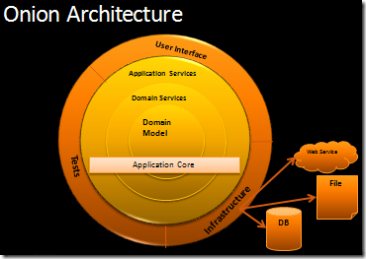

（出所）[The Onion Architecture : part 1 | Programming with Palermo](https://jeffreypalermo.com/2008/07/the-onion-architecture-part-1/)



オニオンアーキテクチャは中心から外側に向かって、おおむね次のような同心円で構成される。

```
┌─────────────────────────────────────┐
│  Infrastructure / Tests / UI          │  ← 外側：DB、外部API、フレームワーク
│  ┌─────────────────────────────────┐ │
│  │  Application Services            │ │  ← ユースケースの調整役
│  │  ┌─────────────────────────────┐ │ │
│  │  │  Domain Services              │ │ │  ← ドメインロジックの一部
│  │  │  ┌───────────────────────┐   │ │ │
│  │  │  │  Domain Model (Core)   │   │ │ │  ← 中心：エンティティ・値オブジェクト
│  │  │  └───────────────────────┘   │ │ │
│  │  └─────────────────────────────┘ │ │
│  └─────────────────────────────────┘ │
└─────────────────────────────────────┘
```

- **依存の方向は常に外側から内側**（外側の層は内側の層を参照できるが、逆はできない）
- 内側の層は外側の層の存在を一切知らない
- インフラストラクチャ（DB、ファイルシステム、外部API、UIなど）はすべて最も外側に位置し、「詳細」として扱われる


## 各層の役割

### 1. Domain Model（中心）

- エンティティや値オブジェクトなど、ビジネスの核となるモデル
- 他のどの層にも依存しない、最も安定した層

```python
class Order:
    def __init__(self, order_id, items):
        self.order_id = order_id
        self.items = items

    def total_price(self):
        return sum(item.price for item in self.items)
```

### 2. Domain Services

- 単一のエンティティに収まらないドメインロジック（複数のドメインオブジェクトにまたがる処理）を扱う
- Domain Model のみに依存する

```python
class PricingService:
    def apply_discount(self, order: Order, discount_rate: float) -> float:
        return order.total_price() * (1 - discount_rate)
```

### 3. Application Services（ユースケース層）

- アプリケーション固有のユースケースを実装し、ドメイン層を調整（オーケストレーション）する
- リポジトリなどの「外側の機能」はインターフェース（抽象）として定義し、実装には依存しない

```python
from abc import ABC, abstractmethod

class OrderRepository(ABC):
    @abstractmethod
    def save(self, order: Order) -> None: ...

    @abstractmethod
    def find_by_id(self, order_id) -> Order: ...


class PlaceOrderService:
    def __init__(self, order_repository: OrderRepository, pricing_service: PricingService):
        self.order_repository = order_repository
        self.pricing_service = pricing_service

    def execute(self, order_id, items, discount_rate):
        order = Order(order_id, items)
        self.pricing_service.apply_discount(order, discount_rate)
        self.order_repository.save(order)
        return order
```

### 4. Infrastructure / UI（最も外側）

- `OrderRepository` の具体的な実装（PostgreSQL、外部API連携など）
- Web API、CLI、バッチ処理といったエントリーポイント
- 内側の層が定義したインターフェースを実装することで「差し込まれる」

```python
class PostgresOrderRepository(OrderRepository):
    def save(self, order: Order) -> None:
        # PostgreSQL固有の実装
        ...

    def find_by_id(self, order_id) -> Order:
        # PostgreSQL固有の実装
        ...
```


:::{margin}

**エンティティ（Entity）**: 属性ではなく同一性（identity）によって識別されるオブジェクト。属性が変わっても同じものとして追跡される（例：ユーザー、注文）。

**値オブジェクト（Value Object）**: 同一性を持たず、属性の値そのものが意味を持つ不変（immutable）なオブジェクト（例：金額、住所、期間）。

詳細は [DDD](../x_driven_development/domain_driven_design.ipynb) を参照。
:::

## 依存性逆転による「インフラの外部化」

オニオンアーキテクチャの核心は、依存性逆転の原則（DIP）を使って **インフラストラクチャをアプリケーションの外側に追い出す** こと。

- 従来の layered architecture（3層アーキテクチャ）では、Presentation → Business Logic → Data Access という一方向の依存になりがちで、ビジネスロジックがデータアクセス層（多くの場合DB）に強く依存してしまう
- オニオンアーキテクチャでは、リポジトリのインターフェースをドメイン／アプリケーション層側で定義し、実装は外側のインフラ層に置く
- これにより、DBやORMを差し替えてもドメインロジックには一切影響が及ばない


## クリーンアーキテクチャとの違い

[クリーンアーキテクチャ](clean_architecture.ipynb)とオニオンアーキテクチャは、依存関係を中心に向かわせるという根本思想は同一で、しばしば区別なく語られる。細かな違いとしては以下が挙げられる。

| 観点 | オニオンアーキテクチャ | クリーンアーキテクチャ |
| --- | --- | --- |
| 提唱者・年 | Jeffrey Palermo, 2008 | Robert C. Martin, 2012 |
| 層の呼び方 | Domain Model / Domain Services / Application Services / Infrastructure | Entities / Use Cases / Interface Adapters / Frameworks & Drivers |
| 強調点 | インフラの外部化・DIPによる「詳細の交換可能性」 | ユースケースを中心とした境界（Boundary）の明確化 |
| 図の形状 | 同心円（玉ねぎ） | 同心円（元祖の図もほぼ同一） |

実務上は、どちらの用語を使っても「ドメイン中心・依存は内向き・インフラは外側の詳細」という同じ設計原則を指していることが多い。[ヘキサゴナルアーキテクチャ](hexagonal_architecture.ipynb)も含め、この3つは「Ports and Adapters系アーキテクチャ」としてまとめて扱われることもある。


## メリット

1. **ドメインロジックの独立性**
   - DB、フレームワーク、外部サービスの変更がドメイン層に波及しない
2. **テスタビリティ**
   - Domain Model / Domain Services / Application Services はインフラなしで単体テスト可能
3. **技術選定の後回し（Late Binding）**
   - 「どのDBを使うか」「どのWebフレームワークを使うか」といった詳細の決定を後回しにできる
4. **保守性**
   - 変更理由（ビジネスルールの変更 vs インフラの都合）ごとに変更箇所が分離される


## デメリット

- **学習コスト**: 依存性逆転やレイヤー分割の考え方に慣れが必要
- **初期コスト**: 小規模・単純なCRUDアプリケーションには過剰な設計になりやすい
- **ボイラープレートの増加**: インターフェースの定義とその実装で二重にコードを書く必要がある
- **境界の判断が難しい**: どのロジックを Domain Service に置き、どれを Application Service に置くかの線引きに迷いやすい


## 適用場面

- ドメインロジックが複雑で、長期にわたり進化していくシステム
- DBやフレームワークなどインフラの選定・変更が将来起こりうるシステム
- [DDD（ドメイン駆動設計）](../x_driven_development/domain_driven_design.ipynb)と組み合わせて、ドメインモデルを中心に据えた設計をしたい場合
- 単純なCRUDが中心で将来の変更もほぼ見込まれない小規模システムには不向き（オーバーエンジニアリングになりやすい）

## 参考文献

- Jeffrey Palermo, ["The Onion Architecture" (blog series, 2008)](https://jeffreypalermo.com/2008/07/the-onion-architecture-part-1/)
- [クリーンアーキテクチャ](clean_architecture.ipynb)
- [ヘキサゴナルアーキテクチャ](hexagonal_architecture.ipynb)